In [2]:
# ---------------------------------------
# OPEN-HOLE WELL LOG INTERPRETATION
# ---------------------------------------

import lasio
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ---------------------------------------
# 1. LOAD LAS FILE
# ---------------------------------------

las = lasio.read("WLC_PETRO_COMPUTED_INPUT_1.LAS")

# Convert LAS file to dataframe
log_data = las.df()

In [4]:
# Check available log curves
print(log_data.columns)


Index(['ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04', 'BS', 'CALI', 'DRHO',
       'GR', 'NBGRCFM', 'NPHI', 'PEF', 'RACEHM', 'RACELM', 'RD', 'RHOB', 'RM',
       'ROP', 'RPCEHM', 'RPCELM', 'RT'],
      dtype='object')


In [5]:
# Preview data
log_data.head()

,ABDCQF01,ABDCQF02,ABDCQF03,ABDCQF04,BS,CALI,DRHO,GR,NBGRCFM,NPHI,PEF,RACEHM,RACELM,RD,RHOB,RM,ROP,RPCEHM,RPCELM,RT
DEPTH,,,,,,,,,,,,,,,,,,,,
145.9,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146.0,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146.1,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146.2,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146.3,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# ---------------------------------------
# 2. CLEAN DATA
# ---------------------------------------

# Replace missing LAS values if present
log_data = log_data.replace(-999.25, pd.NA)

# Drop rows where key logs are missing
log_data = log_data.dropna(subset=["GR", "RHOB", "NPHI"])

# Reset depth index into a column
log_data = log_data.reset_index()

# Rename depth column
log_data = log_data.rename(columns={log_data.columns[0]: "Depth"})

In [16]:
# ---------------------------------------
# 3. SIMPLE SHALE VOLUME ESTIMATION
# ---------------------------------------

# Gamma Ray is used to distinguish clean sand from shale
gr_min = log_data["GR"].min()
gr_max = log_data["GR"].max()

# Calculate shale volume index
log_data["Vsh"] = (log_data["GR"] - gr_min) / (gr_max - gr_min)

# Limit Vsh between 0 and 1
log_data["Vsh"] = log_data["Vsh"].clip(0, 1)

In [17]:
# ---------------------------------------
# 4. BASIC RESERVOIR FLAG
# ---------------------------------------

# Low GR and low Vsh can indicate cleaner reservoir intervals
log_data["Reservoir_Flag"] = log_data["Vsh"] < 0.35


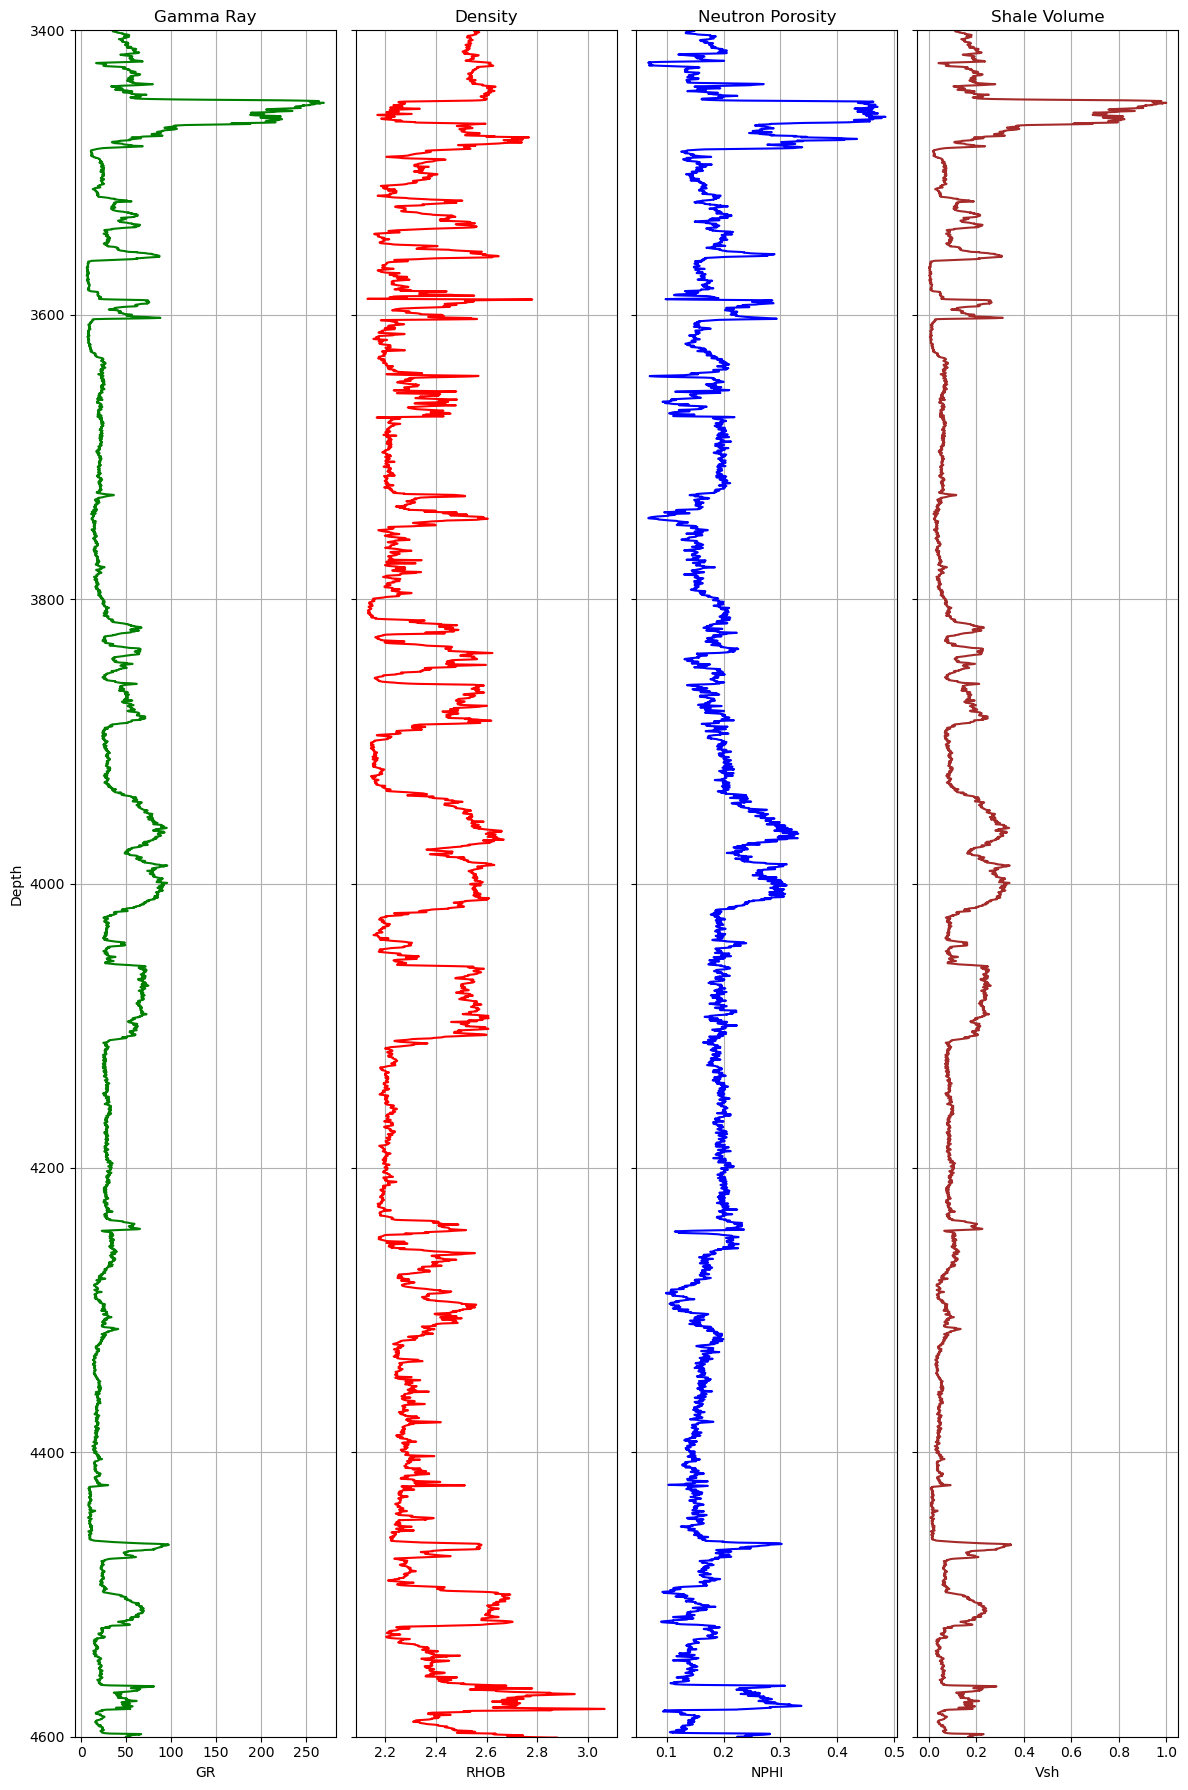

In [20]:
# ---------------------------------------
# 5. PLOT OPEN-HOLE LOGS
# ---------------------------------------

fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(12, 18))

# Gamma Ray track
ax[0].plot(log_data["GR"], log_data["DEPTH"], color="green")
ax[0].set_xlabel("GR")
ax[0].set_title("Gamma Ray")
ax[0].grid(True)

# Bulk Density track
ax[1].plot(log_data["RHOB"], log_data["DEPTH"], color="red")
ax[1].set_xlabel("RHOB")
ax[1].set_title("Density")
ax[1].grid(True)

# Neutron Porosity track
ax[2].plot(log_data["NPHI"], log_data["DEPTH"], color="blue")
ax[2].set_xlabel("NPHI")
ax[2].set_title("Neutron Porosity")
ax[2].grid(True)

# Shale Volume track
ax[3].plot(log_data["Vsh"], log_data["DEPTH"], color="brown")
ax[3].set_xlabel("Vsh")
ax[3].set_title("Shale Volume")
ax[3].grid(True)

# Set depth interval
ax[0].set_ylim(3400, 4600)

# Depth increases downward in well logs
ax[0].invert_yaxis()

# Add y-axis label
ax[0].set_ylabel("Depth")

plt.tight_layout()
plt.savefig("openhole_log_interpretation.png", dpi=300)
plt.show()

In [21]:
# ---------------------------------------
# 6. SUMMARY
# ---------------------------------------

reservoir_intervals = log_data[log_data["Reservoir_Flag"] == True]

print("Number of potential reservoir points:", len(reservoir_intervals))
print("Average Vsh:", log_data["Vsh"].mean())

Number of potential reservoir points: 13361
Average Vsh: 0.11663317958953962
